In [2]:
from bioio import BioImage
from cellpose import models, plot as cpplot, utils
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import block_reduce
from spotiflow.model import Spotiflow

### Defs

In [ ]:
cellpose_models_path = Path.cwd().parent.parent / '_pipeline_assets/cellpose_models/'
cellpose_model_name = 'cpsam_pseudo3d_4x_20260506'
model_cellpose = models.CellposeModel(
        gpu=True,
        pretrained_model=str(cellpose_models_path / cellpose_model_name)
        )

pretrained model /home/michalv/.cellpose/models/cpsam not found, using default model


In [ ]:
spotiflow_models_path = Path.cwd().parent.parent / '_pipeline_assets/bag_spot_model'
model_spotiflow = Spotiflow.from_folder(str(spotiflow_models_path))

AssertionError: Config file /home/michalv/Analysis/_pipeline_assets/config.yaml does not exist.

In [4]:
model_spotiflow.config.is_3d

True

In [6]:
data_folder = Path.cwd().parent / 'data'
file_list = [p for p in data_folder.iterdir() if p.is_file()]
img = BioImage(file_list[2])

In [7]:
len(img.scenes) 

5

In [8]:
img.set_scene(4)
objects_stack = img.get_image_data("ZYX", C=0).astype(np.float32)
spots_stack = img.get_image_data("ZYX", C=1).astype(np.float32)
min_substracted = objects_stack - np.min(objects_stack, axis=0)

In [9]:
min_substracted.shape

(29, 2048, 1744)

In [9]:
img_binned = block_reduce(min_substracted, block_size=(1, 4, 4), func=np.mean)

In [10]:
masks_binned, flows, styles = model_cellpose.eval(
    img_binned,
    z_axis=0,
    do_3D=False,
    stitch_threshold=0.4,
)

100%|██████████| 28/28 [00:00<00:00, 142.90it/s]


In [11]:
masks_resized = masks_binned.repeat(4, axis=-2).repeat(4, axis=-1)

In [12]:
len(masks_resized.shape)

3

In [13]:
unique_masks = np.unique(masks_resized)
print(f"Total detected masks in volume: {len(unique_masks) - 1}")

Total detected masks in volume: 3


In [14]:
masks_cleaned = np.zeros_like(masks_resized)
for z in range(masks_resized.shape[0]):
    masks_cleaned[z] = utils.remove_edge_masks(masks_resized[z], change_index=True)

In [15]:
unique_masks_cleaned = np.unique(masks_cleaned)
print(f"Total detected cleaned masks in volume: {len(unique_masks_cleaned) - 1}")

Total detected cleaned masks in volume: 1


In [16]:
coords_spotiflow, details = model_spotiflow.predict(
    spots_stack,
    prob_thresh=0.5, 
    min_distance=1,
)

INFO:spotiflow.model.spotiflow:Will use device: cuda:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = 0.5, min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (29, 2048, 1744)
INFO:spotiflow.model.spotiflow:Predicting with (1, 8, 7) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (32, 2048, 1760, 1)
INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


Predicting tiles:   0%|          | 0/56 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 11 spots


In [46]:
coords_spotiflow.shape

(11, 3)

In [50]:
coords_spotiflow.shape[1]

3

In [48]:
len(coords_spotiflow)

11

In [49]:
coords_spotiflow[:, 0]

array([10.77999288, 15.84229481, 17.87417603, 11.59566677, 19.35991561,
       19.06380856, 18.7327767 , 19.08450651, 18.55037713, 19.73686957,
       23.15145886])

### Plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.exposure
import skimage.segmentation
import skimage.measure
import cellpose.plot

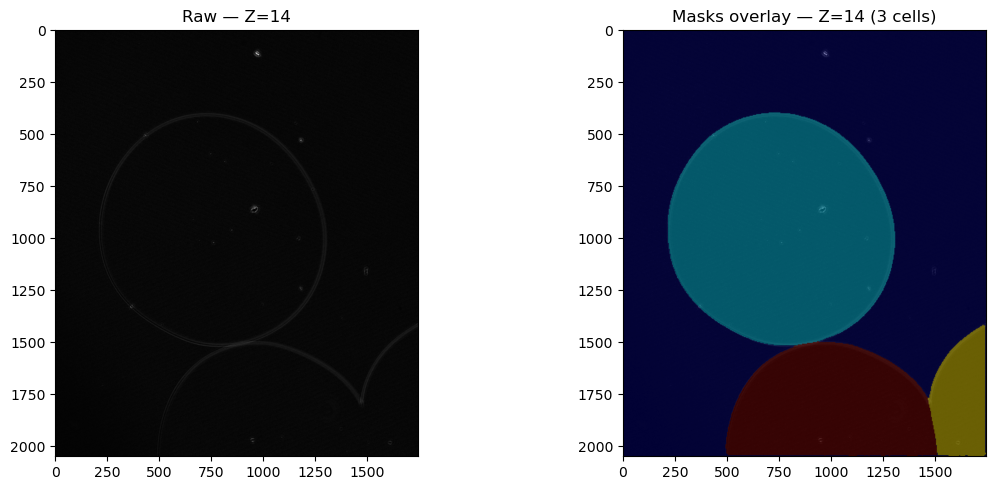

In [ ]:
z = min_substracted.shape[0] // 2  # middle slice

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(min_substracted[z], cmap='gray')
axes[0].set_title(f'Raw — Z={z}')

axes[1].imshow(min_substracted[z], cmap='gray')
axes[1].imshow(masks_resized[z], cmap='jet', alpha=0.4)
axes[1].set_title(f'Masks overlay — Z={z} ({len(np.unique(masks_resized[z]))-1} cells)')

plt.tight_layout()
plt.show()

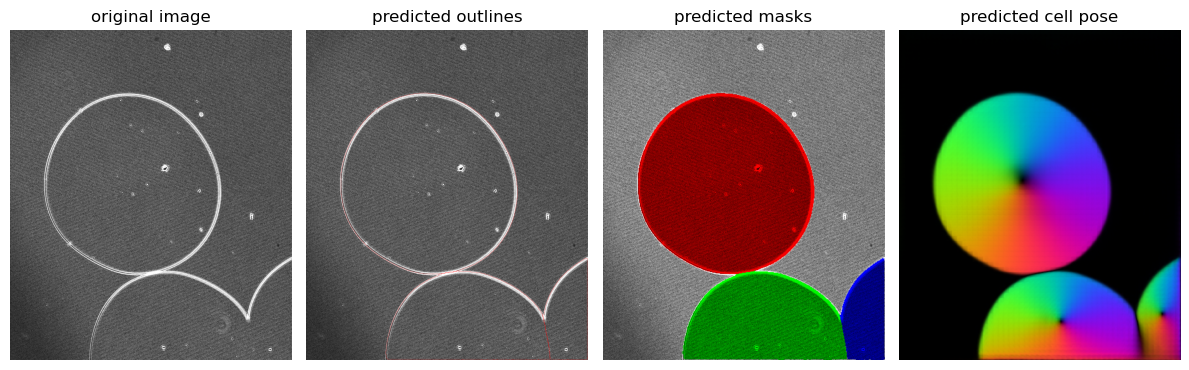

In [37]:
z = min_substracted.shape[0] // 2

fig = plt.figure(figsize=(12, 5))
cpplot.show_segmentation(
    fig,
    min_substracted[z],
    masks_resized[z],
    flows[0][z],      # ← flows[0] is the RGB image, shape (Z, Y, X, 3)
    channels=[0, 0]
)
plt.tight_layout()
plt.show()

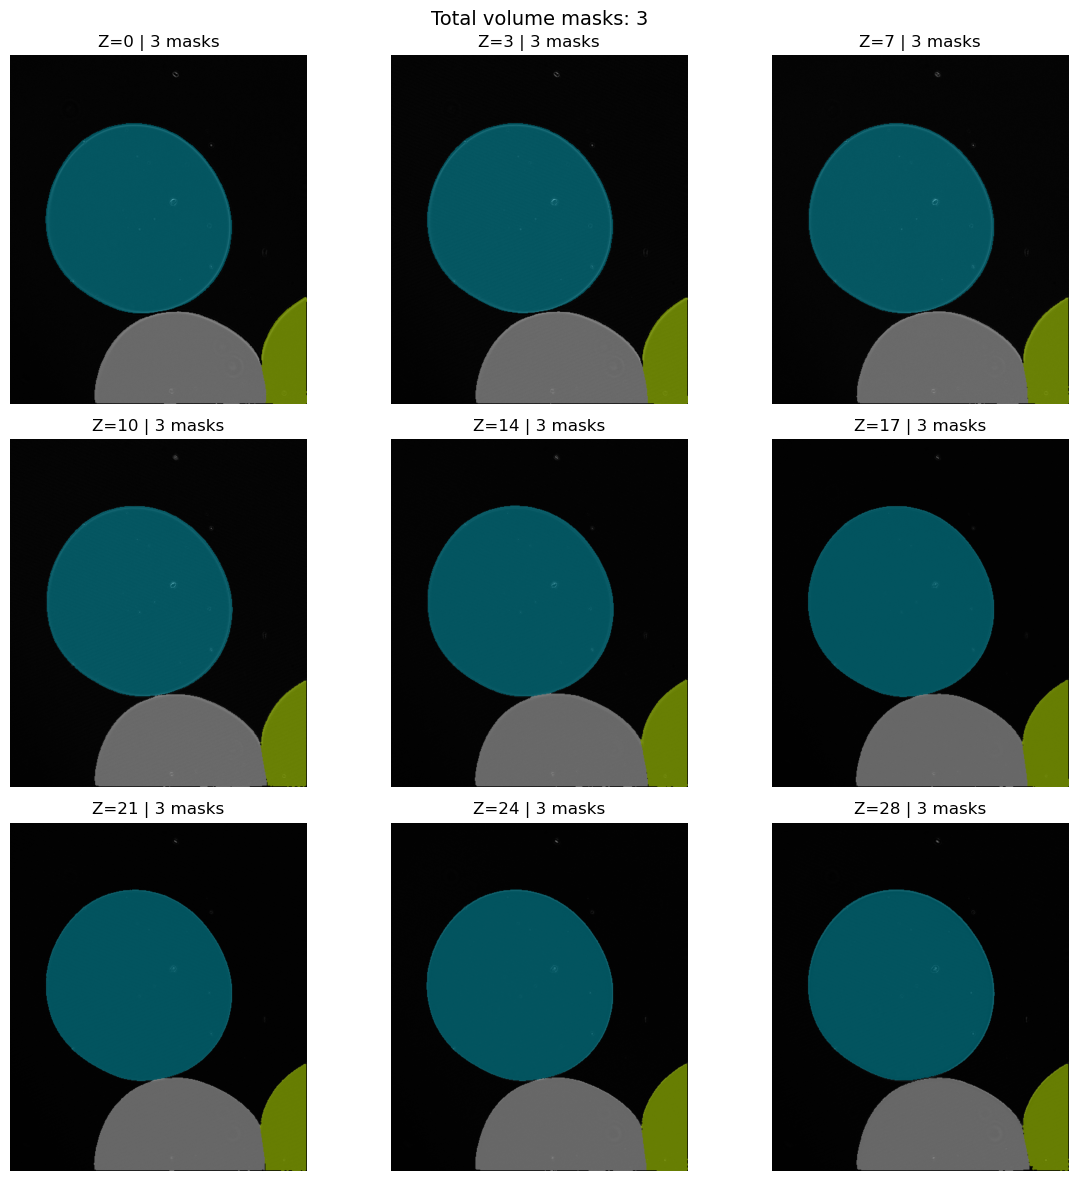

In [38]:
from matplotlib.gridspec import GridSpec

z_indices = np.linspace(0, masks_resized.shape[0]-1, 9, dtype=int)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, z in zip(axes.flat, z_indices):
    ax.imshow(min_substracted[z], cmap='gray')
    ax.imshow(masks_resized[z], cmap='nipy_spectral', alpha=0.5, vmin=0, vmax=masks_resized.max())
    ax.set_title(f'Z={z} | {len(np.unique(masks_resized[z]))-1} masks')
    ax.axis('off')

plt.suptitle(f'Total volume masks: {len(np.unique(masks_resized))-1}', fontsize=14)
plt.tight_layout()
plt.show()

Input shape:  (29, 2048, 1744)
Mask shape:   (29, 2048, 1744)
Cleaned masks: (8192, 6976)


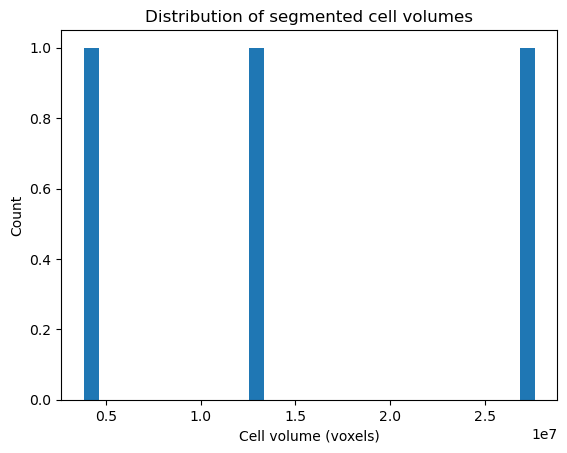

In [39]:
# resample=True means cellpose internally downscaled then upscaled back
# verify mask shape matches your original volume
print(f"Input shape:  {min_substracted.shape}")
print(f"Mask shape:   {masks_resized.shape}")          # should match
print(f"Cleaned masks: {masks_cleaned.shape}") # should also match

# Check object sizes are physiologically reasonable (not artifacts of scaling)
cell_volumes = [(masks_resized == i).sum() for i in np.unique(masks_resized)[1:]]
plt.hist(cell_volumes, bins=30)
plt.xlabel('Cell volume (voxels)')
plt.ylabel('Count')
plt.title('Distribution of segmented cell volumes')
plt.show()